In [78]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
from sklearn.preprocessing import LabelEncoder 
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pickle

In [79]:
data=pd.read_csv('../data/Telco_Customer_Churn_Dataset.csv')

In [80]:
data.size

147903

In [81]:
data.shape

(7043, 21)

In [82]:
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [83]:
pd.set_option('display.max_columns',None)

In [84]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [85]:
data.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [86]:
data=data.drop(columns=['customerID'])

In [87]:
data.head(1)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No


In [88]:
numerical_feature_list= ['tenure', 'MonthlyCharges', 'TotalCharges']
for col in data.columns:
    if col not in numerical_feature_list:
        print(col,data[col].unique())
        print("----")
    

gender <StringArray>
['Female', 'Male']
Length: 2, dtype: str
----
SeniorCitizen [0 1]
----
Partner <StringArray>
['Yes', 'No']
Length: 2, dtype: str
----
Dependents <StringArray>
['No', 'Yes']
Length: 2, dtype: str
----
PhoneService <StringArray>
['No', 'Yes']
Length: 2, dtype: str
----
MultipleLines <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
----
InternetService <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
----
OnlineSecurity <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
----
OnlineBackup <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
----
DeviceProtection <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
----
TechSupport <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
----
StreamingTV <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
----
StreamingMovies <StringArray>
['No', 'Yes', 'No internet service']
Length: 3,

In [89]:
data.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [90]:
data[data['TotalCharges']==' ']

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [91]:
data['TotalCharges']=data['TotalCharges'].replace({' ': '0.0'})

In [92]:
data['TotalCharges']= data['TotalCharges'].astype(float)

In [93]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   str    
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   str    
 3   Dependents        7043 non-null   str    
 4   tenure            7043 non-null   int64  
 5   PhoneService      7043 non-null   str    
 6   MultipleLines     7043 non-null   str    
 7   InternetService   7043 non-null   str    
 8   OnlineSecurity    7043 non-null   str    
 9   OnlineBackup      7043 non-null   str    
 10  DeviceProtection  7043 non-null   str    
 11  TechSupport       7043 non-null   str    
 12  StreamingTV       7043 non-null   str    
 13  StreamingMovies   7043 non-null   str    
 14  Contract          7043 non-null   str    
 15  PaperlessBilling  7043 non-null   str    
 16  PaymentMethod     7043 non-null   str    
 17  Monthl

In [94]:
print(data['Churn'].value_counts())

Churn
No     5174
Yes    1869
Name: count, dtype: int64


In [95]:
def plot_histogram(data, column_name):
    plt.figure(figsize=(5,3))
    sns.histplot(data[column_name],kde=True)
    plt.title(f'Distribution of [column_name]')
    
    
    #mean and median
    col_mean= data[column_name].mean()
    col_median= data[column_name].median()
    
    #adding vertical lines
    plt.axvline(col_mean, color='red', linestyle='--', label='Mean')
    plt.axvline(col_median, color='green', label='Median')
    plt.legend()
    plt.show()

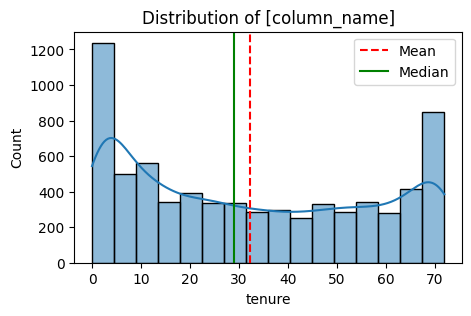

In [96]:
plot_histogram(data, 'tenure')

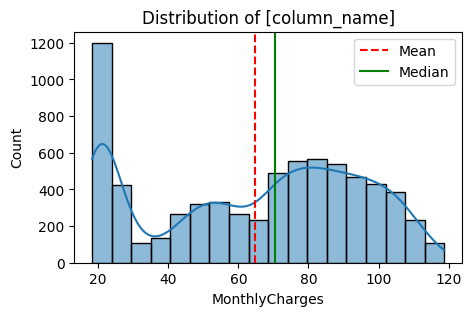

In [97]:
plot_histogram(data, 'MonthlyCharges')

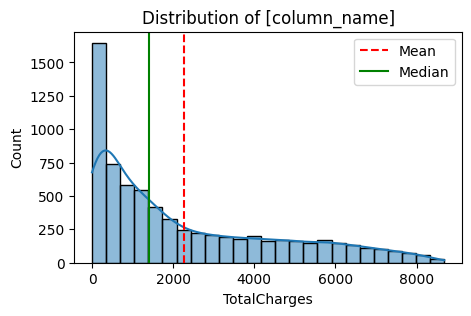

In [98]:
plot_histogram(data, 'TotalCharges')

In [99]:
def plot_boxplot(data, column_name):
    plt.figure(figsize=(5,3))
    sns.boxplot(y=data[column_name])
    plt.title(f"Box plot of {column_name}")
    plt.ylabel(column_name)
    plt.show()

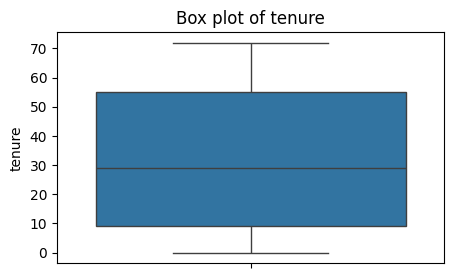

In [100]:
plot_boxplot(data, 'tenure')

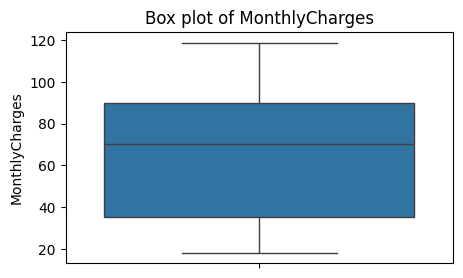

In [101]:
plot_boxplot(data, 'MonthlyCharges')

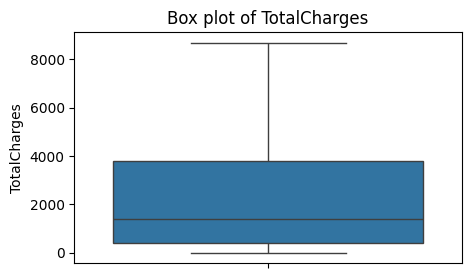

In [102]:
plot_boxplot(data, 'TotalCharges')

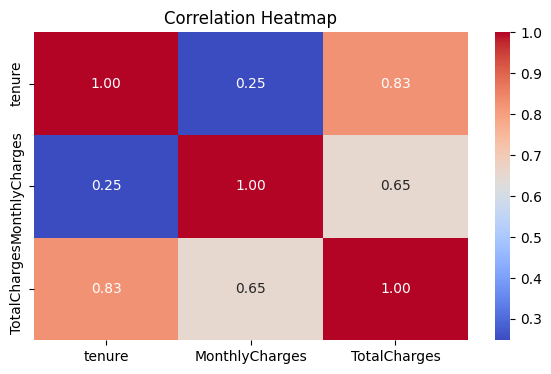

In [103]:
# correlation matrix- heatmap
plt.figure(figsize=(7,4))
sns.heatmap(data[['tenure', 'MonthlyCharges', 'TotalCharges']].corr(),annot=True, cmap='coolwarm', fmt='0.2f')
plt.title('Correlation Heatmap')
plt.show()

C:\Users\dell5480\AppData\Local\Temp\ipykernel_14816\3223341269.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_cols=data.select_dtypes(include='object').columns.to_list()   #countplot for categorical values


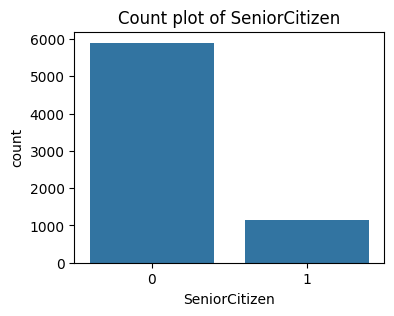

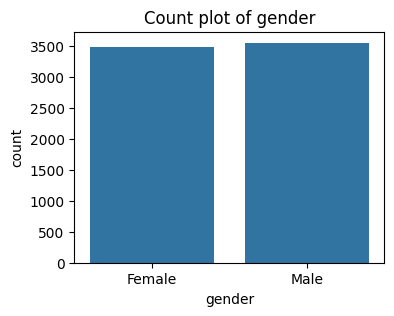

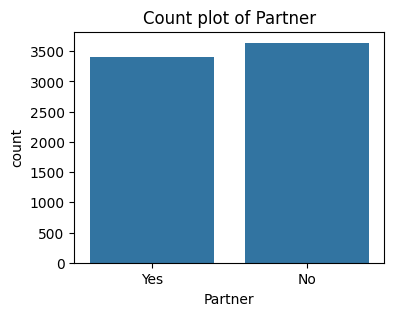

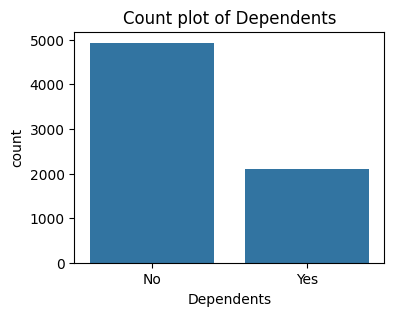

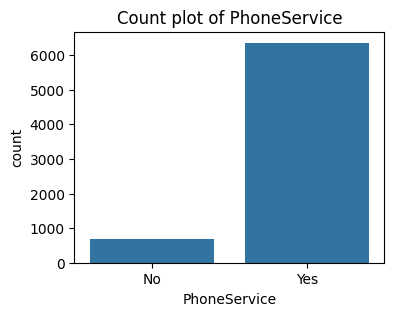

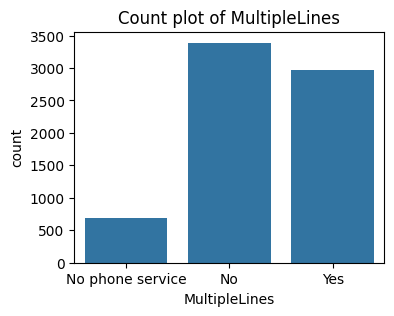

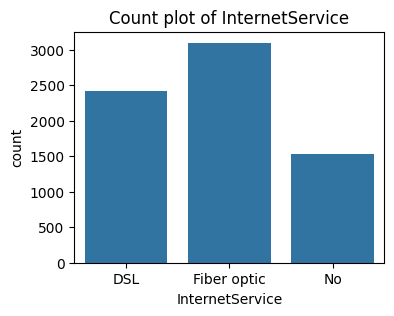

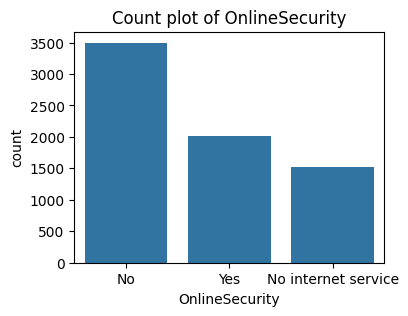

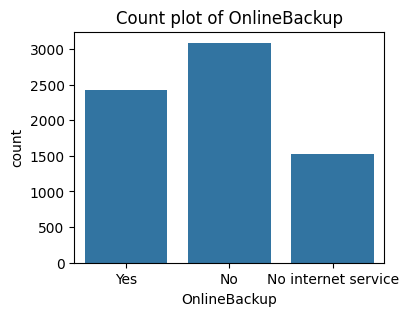

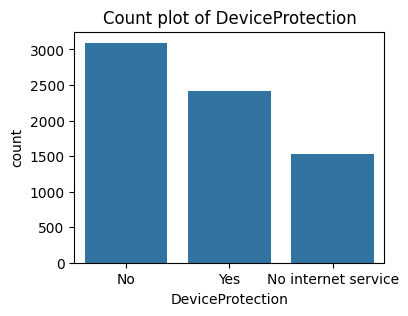

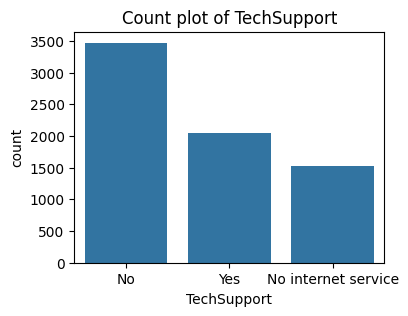

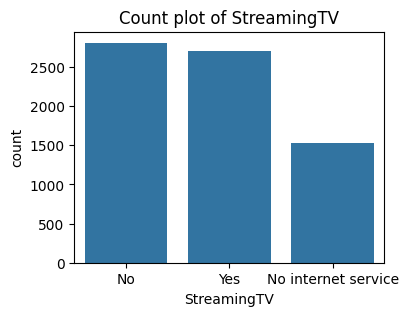

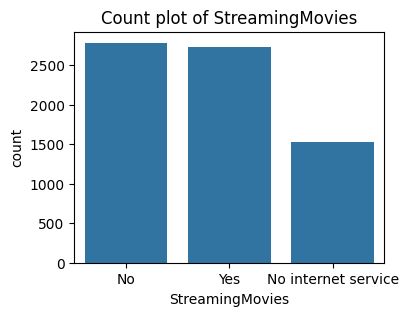

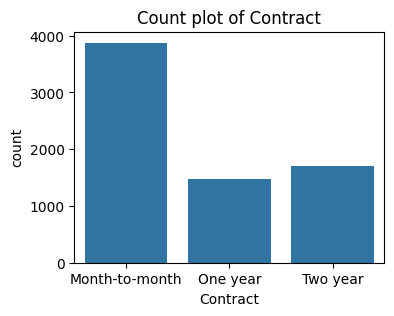

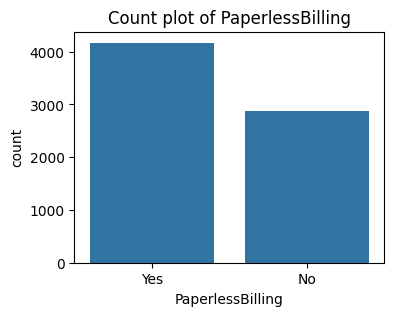

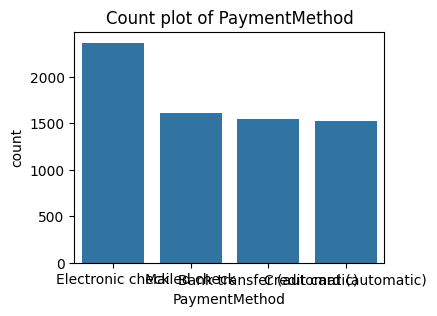

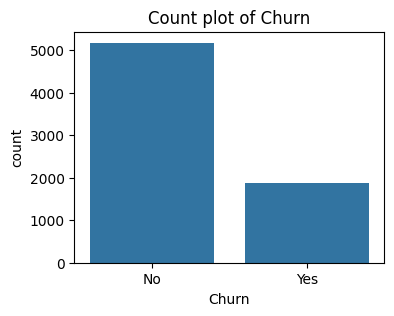

In [104]:
object_cols=data.select_dtypes(include='object').columns.to_list()   #countplot for categorical values
object_cols=['SeniorCitizen'] + object_cols
for col in object_cols:
    plt.figure(figsize=(4,3))
    sns.countplot(x=data[col])
    plt.title(f"Count plot of {col}")
    plt.show()

In [105]:
data['Churn']=data['Churn'].replace({'Yes':1, 'No':0})

* label encoding

In [106]:
object_columns= data.select_dtypes(include='object').columns

C:\Users\dell5480\AppData\Local\Temp\ipykernel_14816\887374608.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  object_columns= data.select_dtypes(include='object').columns


In [107]:
encoders={}
for column in object_columns:
    label_encoder=LabelEncoder()
    data[column]=label_encoder.fit_transform(data[column])
    encoders[column] =label_encoder
    ####making changes to be indented properly
    
with open ('../model/encoders.pkl', 'wb') as f:
    pickle.dump(encoders, f)

In [108]:
data.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50,0
2,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
3,1,0,0,0,45,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75,0
4,0,0,0,0,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1


In [109]:
X=data.drop(columns=['Churn'])
y=data['Churn']

In [110]:
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

In [111]:
print(y_train.value_counts()) #showing imbalance

Churn
0    4138
1    1496
Name: count, dtype: int64


In [112]:
smote= SMOTE(random_state=42)


In [113]:
X_train_smote, y_train_smote=smote.fit_resample(X_train, y_train)

In [114]:
print(y_train_smote.value_counts())

Churn
0    4138
1    4138
Name: count, dtype: int64


In [115]:
#dictionary of models
models={
    'Decision Tree':DecisionTreeClassifier(random_state=42),
    'Random Forest':RandomForestClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42)
}

In [116]:
#dict to store the cross validation results
for model_name, model in models.items():
    print(model_name)
    print(model)
    print("----")

Decision Tree
DecisionTreeClassifier(random_state=42)
----
Random Forest
RandomForestClassifier(random_state=42)
----
XGBoost
XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)
----


In [117]:
cv_scores= {}
for model_name, model in models.items():
    print(f"Training {model_name} with default parameters")
    scores= cross_val_score(model, X_train_smote, y_train_smote,cv=5, scoring='accuracy')
    cv_scores[model_name]=scores
    print(f"{model_name} cross-validation accuracy: {np.mean(scores):.2f}")

Training Decision Tree with default parameters
Decision Tree cross-validation accuracy: 0.78
Training Random Forest with default parameters
Random Forest cross-validation accuracy: 0.84
Training XGBoost with default parameters
XGBoost cross-validation accuracy: 0.83


In [118]:
#intantiating the model
rfc=RandomForestClassifier(random_state=42)

In [119]:
#training model
rfc.fit(X_train_smote, y_train_smote)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [120]:
#evaluation of the model
y_test_pred=rfc.predict(X_test)
print('Accuracy_score:', accuracy_score(y_test, y_test_pred))

print('confusion_matrix: ', confusion_matrix(y_test, y_test_pred))

print("classification_report:", classification_report(y_test, y_test_pred))

Accuracy_score: 0.7771469127040455
confusion_matrix:  [[879 157]
 [157 216]]
classification_report:               precision    recall  f1-score   support

           0       0.85      0.85      0.85      1036
           1       0.58      0.58      0.58       373

    accuracy                           0.78      1409
   macro avg       0.71      0.71      0.71      1409
weighted avg       0.78      0.78      0.78      1409



In [121]:
#saving the trained model
model_data= {"model":rfc, 'features_names': X.columns.tolist()}
with open ('../model/customer_churn_model.pkl','wb') as f:
    pickle.dump(model_data, f)

In [122]:
#loading the saved model and the feature names
with open ('../model/customer_churn_model.pkl', 'rb') as f:
    model_data= pickle.load(f)
    
    loaded_model = model_data['model']
    feature_names= model_data['features_names']

In [123]:
print(loaded_model)

RandomForestClassifier(random_state=42)


In [124]:
input_data={
   
    "gender": "Female",
    "SeniorCitizen": 0,
    "Partner": "Yes", 
    "Dependents": "No",
    "tenure": 1,
    "PhoneService": "No",
    "MultipleLines": "No phone service",
    "InternetService": "DSL",
    "OnlineSecurity": "No",
    "OnlineBackup": "Yes",
    "DeviceProtection": "No",
    "TechSupport": "No",
    "StreamingTV": "No",
    "StreamingMovies": "No",
    "Contract": "Month-to-month",
    "PaperlessBilling": "Yes",
    "PaymentMethod": "Electronic check",
    "MonthlyCharges": 29.85,
    "TotalCharges": 29.85
    
}
input_data_df=pd.DataFrame([input_data])
with open('../model/encoders.pkl', 'rb')as f:
    encoders= pickle.load(f)
    
    
#encoding categorical features using the saved encoders
for column, encoder in encoders.items():
    if column in input_data_df.columns:
        val = str(input_data_df[column].iloc[0])
        if val in encoder.classes_:
            input_data_df[column] = encoder.transform([val])[0]
        else:
            input_data_df[column] = encoder.transform([encoder.classes_[0]])[0]
        
#making prediciton
prediction= loaded_model.predict(input_data_df)
pred_prob=loaded_model.predict_proba(input_data_df)
print(prediction)

#result
print(f"Prediction: {'Churn' if prediction[0]==1 else "No Churn"}")
print(f"Prediction Probability : {pred_prob}")

[0]
Prediction: No Churn
Prediction Probability : [[0.79 0.21]]
